# Progetto Finale: Riconoscimento Gesti della Mano
## Sviluppo di una CNN con Data Augmentation per Sasso, Carta, Forbice

Implementazione completa secondo la consegna: Data Pipeline, Augmentation, CNN, Training con callback su `val_accuracy`, Test su dataset CGI e foto reale.

## 1. Setup e Download Dataset

Scarichiamo i dataset di Laurence Moroney: training e test set. Su Colab usiamo `wget`.

In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop

# Updated URLs for the Rock-Paper-Scissors dataset
RPS_URL = "https://storage.googleapis.com/learning-datasets/rps.zip"
RPS_TEST_URL = "https://storage.googleapis.com/learning-datasets/rps-test-set.zip"

!wget --no-check-certificate -O /tmp/rps.zip "$RPS_URL"
!wget --no-check-certificate -O /tmp/rps-test-set.zip "$RPS_TEST_URL"

# Extraction logic
local_zip = '/tmp/rps.zip'
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('/tmp/')

local_zip = '/tmp/rps-test-set.zip'
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('/tmp/')

print("Dataset successfully extracted.")
print("Training classes:", os.listdir('/tmp/rps'))
print("Test classes:", os.listdir('/tmp/rps-test-set'))

--2026-05-15 14:33:19--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.126.207, 74.125.132.207, 74.125.201.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.126.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M   108MB/s    in 1.8s    

2026-05-15 14:33:21 (108 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2026-05-15 14:33:21--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.126.207, 74.125.132.207, 74.125.201.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.126.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-set.zip’

/tmp/rps-t

## 2. Esplorazione struttura e conteggio immagini

Verifichiamo che le sottocartelle (/rock, /paper, /scissors) siano corrette.

In [5]:
def conta_immagini(base_dir):
    for classe in sorted(os.listdir(base_dir)):
        path = os.path.join(base_dir, classe)
        if os.path.isdir(path):
            print(f"{classe}: {len(os.listdir(path))} immagini")

print("--- Training ---")
conta_immagini('/tmp/rps')
print("\n--- Test ---")
conta_immagini('/tmp/rps-test-set')

--- Training ---
paper: 840 immagini
rock: 840 immagini
scissors: 840 immagini

--- Test ---
paper: 124 immagini
rock: 124 immagini
scissors: 124 immagini


## 3. Fase A: Data Pipeline e Augmentation

Utilizziamo `ImageDataGenerator` con i parametri esatti richiesti dalla consegna:
- `rescale=1./255`
- `rotation_range=40`
- `width_shift_range=0.2`
- `shear_range=0.2`
- `horizontal_flip=True`
- `fill_mode='nearest'`

Creiamo generatori training/validation con `validation_split=0.2` per monitorare `val_accuracy`.

In [7]:
TRAINING_DIR = '/tmp/rps/'
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 32
IMG_SIZE = (150, 150)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print("\nClassi (ordine alfabetico):", train_generator.class_indices)

Found 2016 images belonging to 3 classes.
Found 504 images belonging to 3 classes.

Classi (ordine alfabetico): {'paper': 0, 'rock': 1, 'scissors': 2}


## 4. Fase B: Architettura della CNN

Rete sequenziale con:
- Input 150x150x3
- Blocchi Conv2D + MaxPooling2D con filtri crescenti (32 → 64 → 128)
- Flatten + Dense 512 (relu)
- Output Dense 3 (softmax)

In [8]:
model = tf.keras.models.Sequential([
    # Blocco 1
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    # Blocco 2
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Blocco 3
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Blocco 4 (opzionale, aumenta capacità)
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Classificatore
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Fase C: Compilazione e Training

- Optimizer: Adam
- Loss: `categorical_crossentropy`
- Metrica: `accuracy`
- Callback personalizzata: interrompe se `val_accuracy >= 0.98`
- Epoche: 10

In [10]:
class StopAtValAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.98):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= self.target:
            print(f"\n>>> Val accuracy {val_acc:.4f} ha superato il target {self.target}. Training interrotto.\n")
            self.model.stop_training = True

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 10

callbacks = [
    StopAtValAccuracy(target=0.98)
]

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4712 - loss: 0.9974 - val_accuracy: 0.5833 - val_loss: 0.7756
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8829 - loss: 0.3029 - val_accuracy: 0.8313 - val_loss: 0.4042
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9568 - loss: 0.1363 - val_accuracy: 0.8433 - val_loss: 0.3945
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9816 - loss: 0.0627 - val_accuracy: 0.9087 - val_loss: 0.2350
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9722 - loss: 0.0696 - val_accuracy: 0.8591 - val_loss: 0.3638
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9826 - loss: 0.0492 - val_accuracy: 0.8115 - val_loss: 0.4399
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9891 - loss: 0.0362 - val_accuracy: 0.7837 - val_loss: 0.6151
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.8492 - v

## 6. Visualizzazione andamento training

Grafico di loss e accuracy su training/validation.

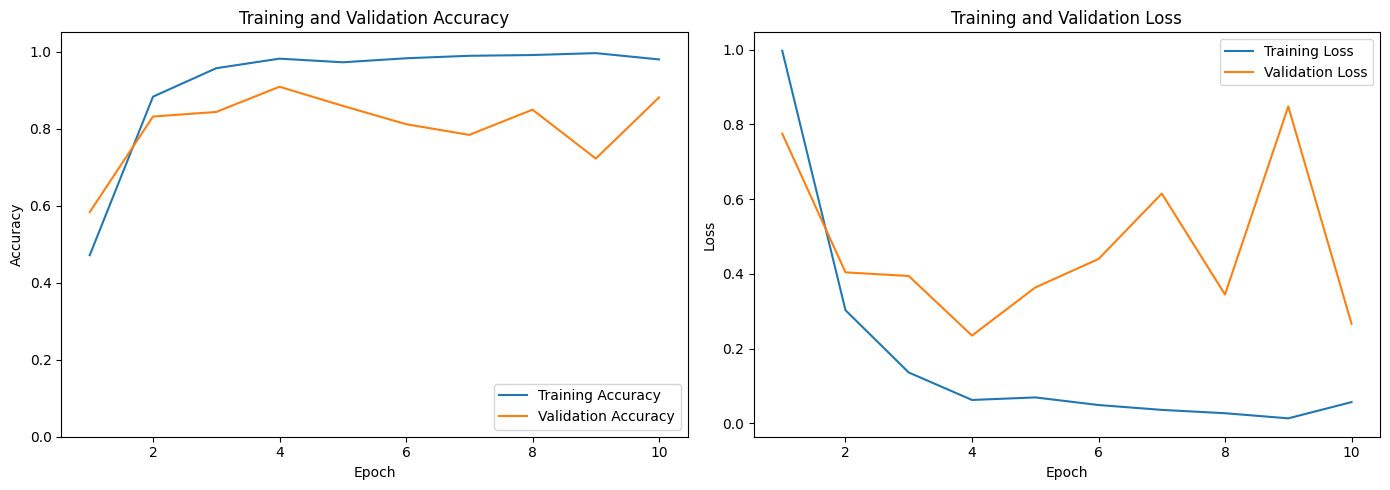

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


## 7. Fase D: Validazione sul Test Set

Valutiamo il modello sulle immagini CGI del test set, con lo stesso preprocessing (rescale 1/255, 150x150).

In [13]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/tmp/rps-test-set',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Test set classi:", test_generator.class_indices)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Found 372 images belonging to 3 classes.
Test set classi: {'paper': 0, 'rock': 1, 'scissors': 2}
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 482ms/step - accuracy: 0.9677 - loss: 0.1394

Test Loss: 0.1394
Test Accuracy: 0.9677


## 8. Test Reale: Classificazione immagine caricata da file

Carica una foto della tua mano (sasso, carta o forbice) su sfondo chiaro. Il modello la ridimensiona a 150x150 e normalizza.

Saving WhatsApp Image 2026-05-15 at 16.29.38.jpeg to WhatsApp Image 2026-05-15 at 16.29.38.jpeg

--- File: WhatsApp Image 2026-05-15 at 16.29.38.jpeg ---
Predizione: rock (confidenza: 41.22%)
Probabilità per classe: {'paper': np.float32(0.29151693), 'rock': np.float32(0.4121557), 'scissors': np.float32(0.29632738)}


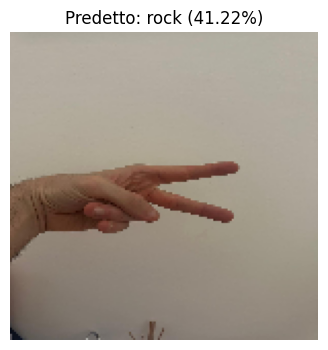

In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload immagine
uploaded = files.upload()

class_names = ['paper', 'rock', 'scissors']  # ordine alfabetico di flow_from_directory

for fn in uploaded.keys():
    print(f"\n--- File: {fn} ---")

    # Carica e preprocessa
    img = image.load_img(fn, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = x / 255.0  # normalizzazione come il training
    x = np.expand_dims(x, axis=0)

    # Predizione
    predictions = model.predict(x, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    print(f"Predizione: {predicted_class} (confidenza: {confidence:.2%})")
    print(f"Probabilità per classe: {dict(zip(class_names, predictions[0]))}")

    # Mostra immagine
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predetto: {predicted_class} ({confidence:.2%})")
    plt.axis('off')
    plt.show()